# Data Preprocessing For Gold Price Forecasting
The **Gold Price Forecasting** is a machine learning project focused on forecasting future gold prices using historical market data and relevant economic indicators. The model leverages time-series features such as past gold prices, USD index, crude oil prices, stock market indices, and inflation-related variables to identify patterns and trends.

# **Import Libraries**

In [1]:
# import libraries
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# **Load Dataset**

In [2]:
# reading file path
file = Path(r"../data/price_data.csv")

# reading csv file
df = pd.read_csv(file)

In [3]:
# testing dataset
df.head(10)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180000,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285000,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167000,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053000,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590000,1.557099
5,1/9/2008,1409.130005,86.550003,75.250000,15.520000,1.466405
6,1/10/2008,1420.329956,88.250000,74.019997,16.061001,1.480100
7,1/11/2008,1401.020020,88.580002,73.089996,16.077000,1.479006
8,1/14/2008,1416.250000,89.540001,74.250000,16.280001,1.486900
9,1/15/2008,1380.949951,87.989998,72.779999,15.834000,1.480210


In [4]:
# shape of the dataset
rows, col = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {col}")

Number of rows: 2290
Number of columns: 6


# **Sanity Check**

In [5]:
# quick overview of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [6]:
# dataset description
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [7]:
#  dataset columns
df.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

In [8]:
# converting date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

In [9]:
df['Date'].head()

0   2008-01-02
1   2008-01-03
2   2008-01-04
3   2008-01-07
4   2008-01-08
Name: Date, dtype: datetime64[ns]

## **Check for Duplicates**

In [10]:
# check duplicates values
df.duplicated().sum()

0

## **Check for null values**

In [11]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [12]:
# parse date and set it as index
df = df.set_index('Date').sort_index()
df.index.name

'Date'

# **Exploratory Data Analysis (EDA)**

In [13]:
# Set style
sns.set(style="whitegrid")

## **Univariate Analysis**

### **Analyze the Target Variable**

#### ***Trend & Volatility check***

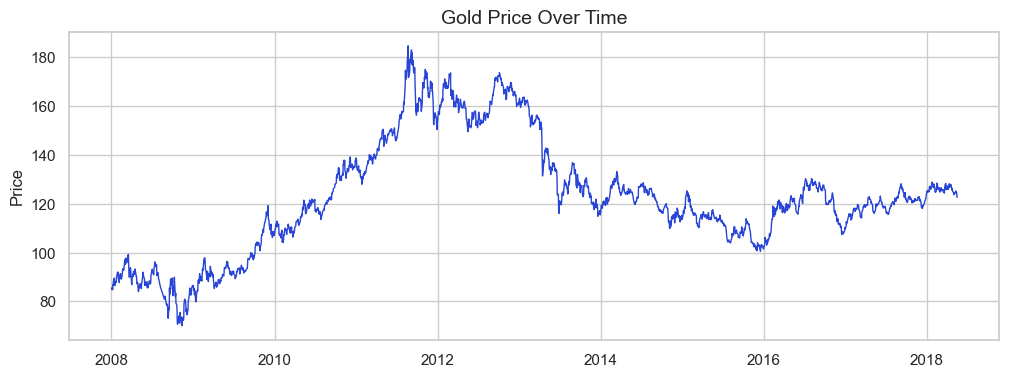

In [14]:
# plot sizing
plt.figure(figsize=(12, 4))

# Time Series Plot
plt.plot(df.index, df['GLD'], linewidth=1, color='#2845D6')
plt.title('Gold Price Over Time', fontsize=14)
plt.ylabel('Price')
plt.show()

**Plot Analysis**

**Key Observations**
- Time Period: 2008 to 2018 (~10 years)
- Price Range: ~$70 to ~$185
- Clear Trend Phases:
    - 2008-2011: Strong upward trend (bull market)
    - 2011-2012: Peak around $180-185
    - 2012-2016: Downward trend (bear market)
    - 2016-2018: Sideways/stable consolidation
- Volatility: Visible price fluctuations throughout, especially during 2008-2012

**Key Takeaways**
- Non-Stationary Data: Clear trend present
- Structural Breaks: Major shift around 2011-2012 (likely due to financial crisis aftermath)
- Time-Dependent: Price at time `t` is clearly influenced by previous periods
- Problem for ML Models: Most traditional ML models assume independent observations, but this shows strong temporal dependency

**Decisions/Actions**
- DO NOT NEED TO: feed raw price directly to ML models
- NEED TO: Create stationary series
- NEED TO: Add time-based features or lag features
- NEED TO: Consider log transformation to stabilize variance

#### ***Stationarity Check***

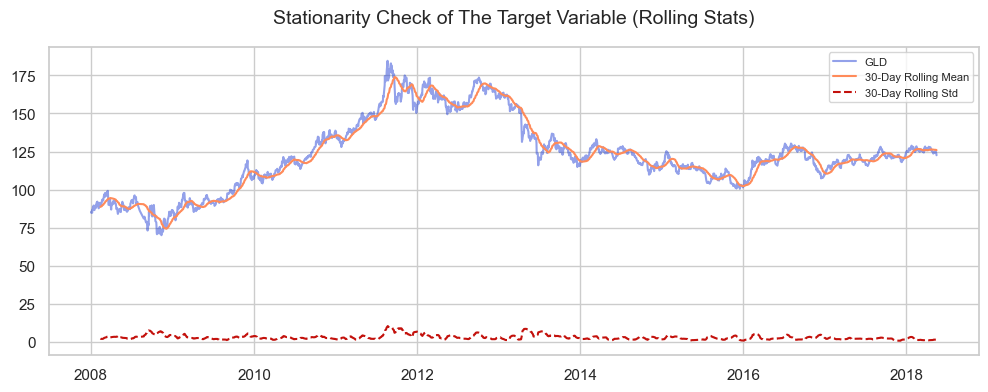

In [15]:
# plot sizing
plt.figure(figsize=(12, 4))

# Rolling Mean & Std
rolling_mean = df['GLD'].rolling(window=30).mean()
rolling_std = df['GLD'].rolling(window=30).std()

plt.plot(df.index, df['GLD'], label='GLD', alpha=0.5, color='#2845D6')
plt.plot(df.index, rolling_mean, label='30-Day Rolling Mean', color='#FF8B5A')
plt.plot(df.index, rolling_std, label='30-Day Rolling Std', color='#C3110C', linestyle='--')
plt.title('Stationarity Check of The Target Variable (Rolling Stats)', fontsize=14, y=1.05)
plt.legend(fontsize=8)
plt.show()

**Plot Analysis**

**Key Observations**
-  Rolling Mean (Orange Line):
    - NOT constant - follows the same trend as price
    - Rises from ~$85 (2008) to ~$170 (2012)
    - Falls to ~$120 (2016)
    - Slight rise toward 2018
- Rolling Std (Red Dashed Line):
    - NOT constant - changes over time
    - 2008-2011: Low volatility (~$2-5)
    - 2011-2012: Spike in volatility (~$8-10) ← Market stress period
    - 2013-2018: Lower but variable volatility (~$3-5)

**Key Takeaways**
- CONFIRMED NON-STATIONARY:
    - Mean is time-dependent (violates stationarity assumption)
    - Variance changes over time (heteroscedasticity)
- Violates ARIMA/Traditional Time Series Assumptions
    - These models require stationarity
- Volatility Clustering: High volatility periods cluster together (2011-2012), typical of financial data
- Spurious Regression Risk
    - Using non-stationary data can lead to false correlations

**Decisions/Actions**
- MUST DIFFERENCE the data (1st order differencing) to remove trend
- CONSIDER LOG transformation before differencing to stabilize variance
- TEST formally with Augmented Dickey-Fuller (ADF) test after visual inspection
- For ML Models: Use returns (% change) instead of raw prices
- For Time Series Models: Use differenced series or model the trend explicitly

#### ***Autocorrelation Function (ACF)***

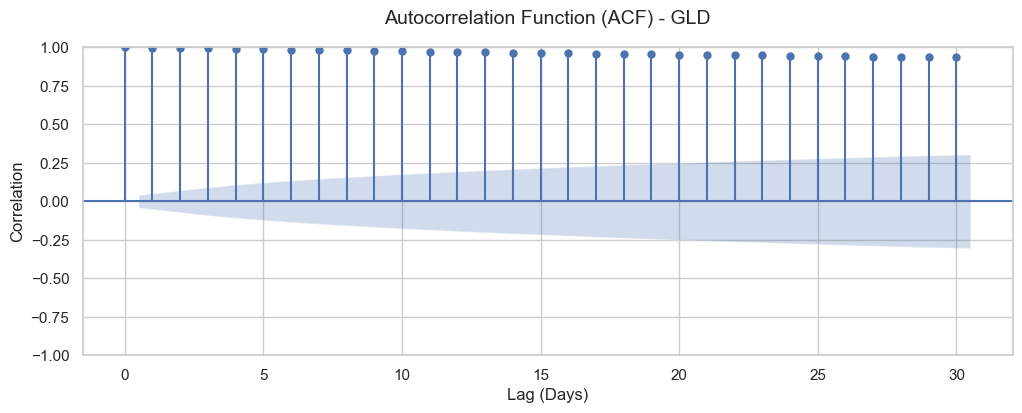

In [16]:
# plot sizing
plt.figure(figsize=(12, 4))

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['GLD'], lags=30, ax=plt.gca(), alpha=0.05)
plt.title('Autocorrelation Function (ACF) - GLD', fontsize=14, y=1.05)
plt.xlabel('Lag (Days)')
plt.ylabel('Correlation')
plt.show()

**Plot Analysis**

**Key Observations**
- All lags (0-30) show correlation ≈ 1.0 (extremely high)
- No decay pattern - correlations stay near 1.0 across all 30 days
- All bars well above confidence interval (shaded blue area)
- Slow/No decay indicates strong persistence

**Key Takeaways**
- Classic Non-Stationary Signature:
    - This is the textbook ACF pattern for a non-stationary series with a trend
    - Each day's price is almost perfectly correlated with previous days
    - The series has `long memory` - past values strongly influence future values
- Implications:
    - Random Walk Behavior: Price today ≈ Price yesterday + small change
    - Spurious Correlation Risk: High autocorrelation can create false patterns
    - Model Violation: ARIMA and many statistical models assume ACF decays to zero
- What This Confirms:
    - Visual inspection (rolling stats) was correct - data is non-stationary
    - Differencing is MANDATORY before modeling
    - After 1st differencing, ACF should drop to near-zero quickly

**Decisions/Actions**
- For Time Series Models:
    - Apply 1st order differencing (d=1)
    - After differencing, ACF should show quick decay
- For ML Models:
    - Use returns instead of raw prices
    - This automatically removes the autocorrelation
- For Both Approaches:
    - DO NOT use raw GLD prices as target
    - Transform to stationary series first

#### ***Data Distribution and Outliers Check***

In [17]:
# Define plot configurations
plots = [
    {
        "func": sns.histplot,
        "kwargs": {"data": df, "x": "GLD", "kde": True, "color": "#2845D6"},
        "title": "GLD Distribution",
        "xlabel": "Price"
    },
    {
        "func": sns.boxplot,
        "kwargs": {"x": df["GLD"], "color": "#28D68D"},
        "title": "GLD Outliers Check",
        "xlabel": None
    }
]

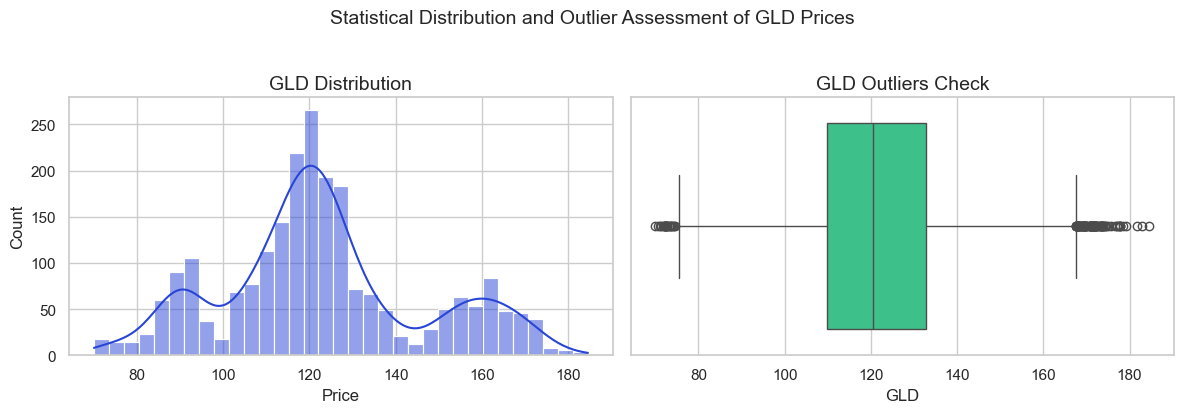

In [18]:
# plot figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop through axes and plot configurations
for ax, plot in zip(axes, plots):
    plot["func"](ax=ax, **plot["kwargs"])
    ax.set_title(plot["title"], fontsize=14)
    
    if plot["xlabel"]:
        ax.set_xlabel(plot["xlabel"])

plt.suptitle("Statistical Distribution and Outlier Assessment of GLD Prices", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

**Plot Analysis**

**Key Observations**

Data Distribution For Density:
- Multi-Modal Distribution: Three distinct peaks visible:
    - Peak 1: ~$90-95 (2008-2009 period)
    - Peak 2: ~$120 (main concentration - 2010, 2016-2018)
    - Peak 3: ~$160-165 (2011-2012 peak period)
- NOT Normal: Clear violation of Gaussian distribution
- Wide Spread: Range from ~$70 to ~$185
- KDE Curve: Confirms the multi-modal pattern

Box Plot For Outliers:
- Outliers Present: Multiple outliers on both ends
    - Lower outliers: ~$70-80 range (2008 crisis lows)
    - Upper outliers: ~$170-185 range (2011-2012 peaks)
- Wide IQR: Large interquartile range indicates high variability
- Long Whiskers: Extended range confirms non-stationarity

**Key Takeaways**
- Multi-Modality = **`Non-Stationarity Confirmed`**:
    - Each mode represents a different market regime
    - This is a direct consequence of the trend we observed earlier
    - The price `lived` in different ranges at different times
- Outliers are NOT Errors:
    - These are real market events (financial crisis, gold rush)
    - DO NOT remove - they contain valuable information
    - They represent structural breaks in the series
- Distribution Implications:
    - Violates normality assumption of many statistical models
    - Raw prices are unsuitable for modeling
    - After transformation (returns/differencing), distribution should normalize
- Critical Insight: The multi-modal distribution is expected for non-stationary price data. Once we convert to returns, we should see a single mode, near normal distribution centered around 0.

**Decisions/Actions**
- DO:
    - Transform to returns or differenced series (this will normalize the distribution)
    - Keep outliers (they're real events)
    - Use robust scaling (not standard scaling) if needed
- DO NOT:
    - Remove outliers (we'll lose critical market event information)
    - Use raw prices for modeling
    - Apply standard normalization on raw prices

### **Analyze The Features**

In [19]:
# exclude target variable
features = [col for col in df.columns if col != 'GLD']

# set grid size dynamically
# ceil division for rows
rows = (len(features) + 1) // 2
cols = 2

#### ***Trend & Volatility check***

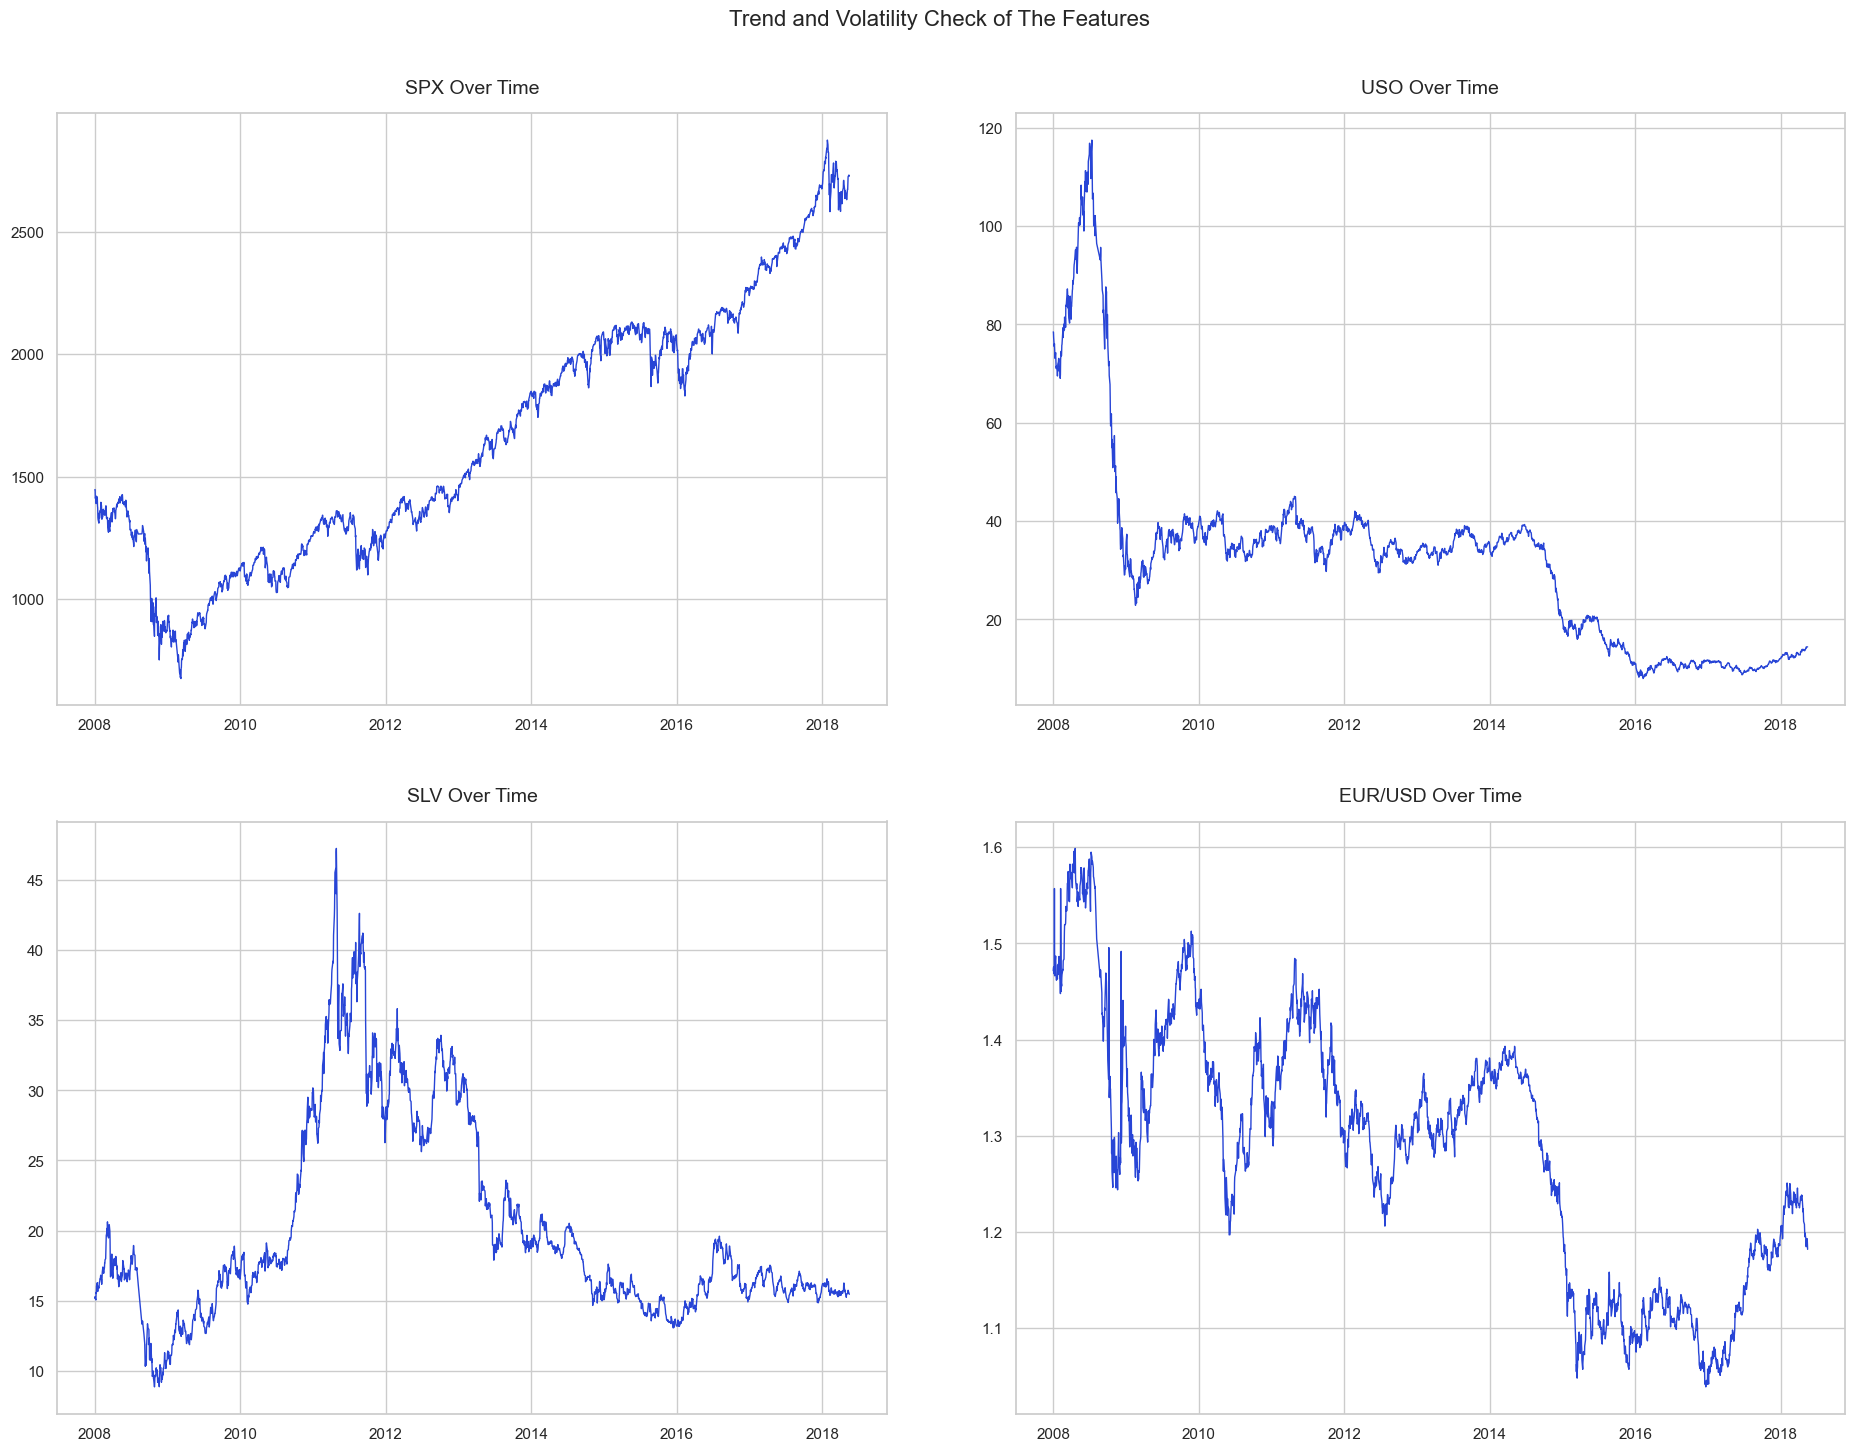

In [20]:
# create subplots
# flatten to 1D for easy indexing
fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
axes = axes.flatten()

fig.tight_layout(pad=5.0)
fig.suptitle('Trend and Volatility Check of The Features', fontsize=16, y=1.01)

# Time-Series Plot
for i, col in enumerate(features):
    axes[i].plot(df.index, df[col], linewidth=1, color='#2845D6')
    axes[i].set_title(f"{col} Over Time", fontsize=14, y=1.02)

# remove unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.show()

**Plot Analysis**

**Key Observations**
| Feature       | Visual Pattern                                        | Behavior                                        |
| ------------- | ----------------------------------------------------- | ----------------------------------------------- |
| SPX (S&P 500) | Strong upward trend (especially 2009–2018)            | Non-stationary (Growth trend)                   |
| USO (Oil)     | Massive spike in 2008, crash, then sideways/decline   | Highly volatile & non-stationary                |
| SLV (Silver)  | Mirrors GLD almost exactly (Peak 2011, decline after) | Non-stationary (Highly correlated with target)  |
| EUR/USD       | Oscillates between 1.0–1.6, but has multi-year trends | Mean-reverting but non-stationary in short term |

**Key Takeaways**
- All Features are Non-Stationary:
    - Just like GLD, all features have time-dependent means and variances.
    - Problem: We cannot mix a stationary target (returns) with non-stationary features (raw prices). This causes model instability.
- USO Volatility:
    - USO shows extreme volatility in 2008.
    - Risk: This feature might introduce noise unless smoothed or transformed.
- Consistency is Key:
    - Since we decided to transform GLD to Returns, we MUST transform all features to Returns as well.
    - This puts all variables on the same scale (% change) and ensures stationarity across the board.

**Decisions/Actions**
- DO:
    - Transform ALL numerical columns (Target + Features) to Percentage Returns.
    - Keep the outliers (they represent real market shocks).
- DO NOT:
    - Mix raw prices with returns (e.g., predicting GLD Returns using SPX Raw Price).
    - Remove the 2008 crisis data (models need to learn from volatility).

#### ***Data Distribution of Other Features***

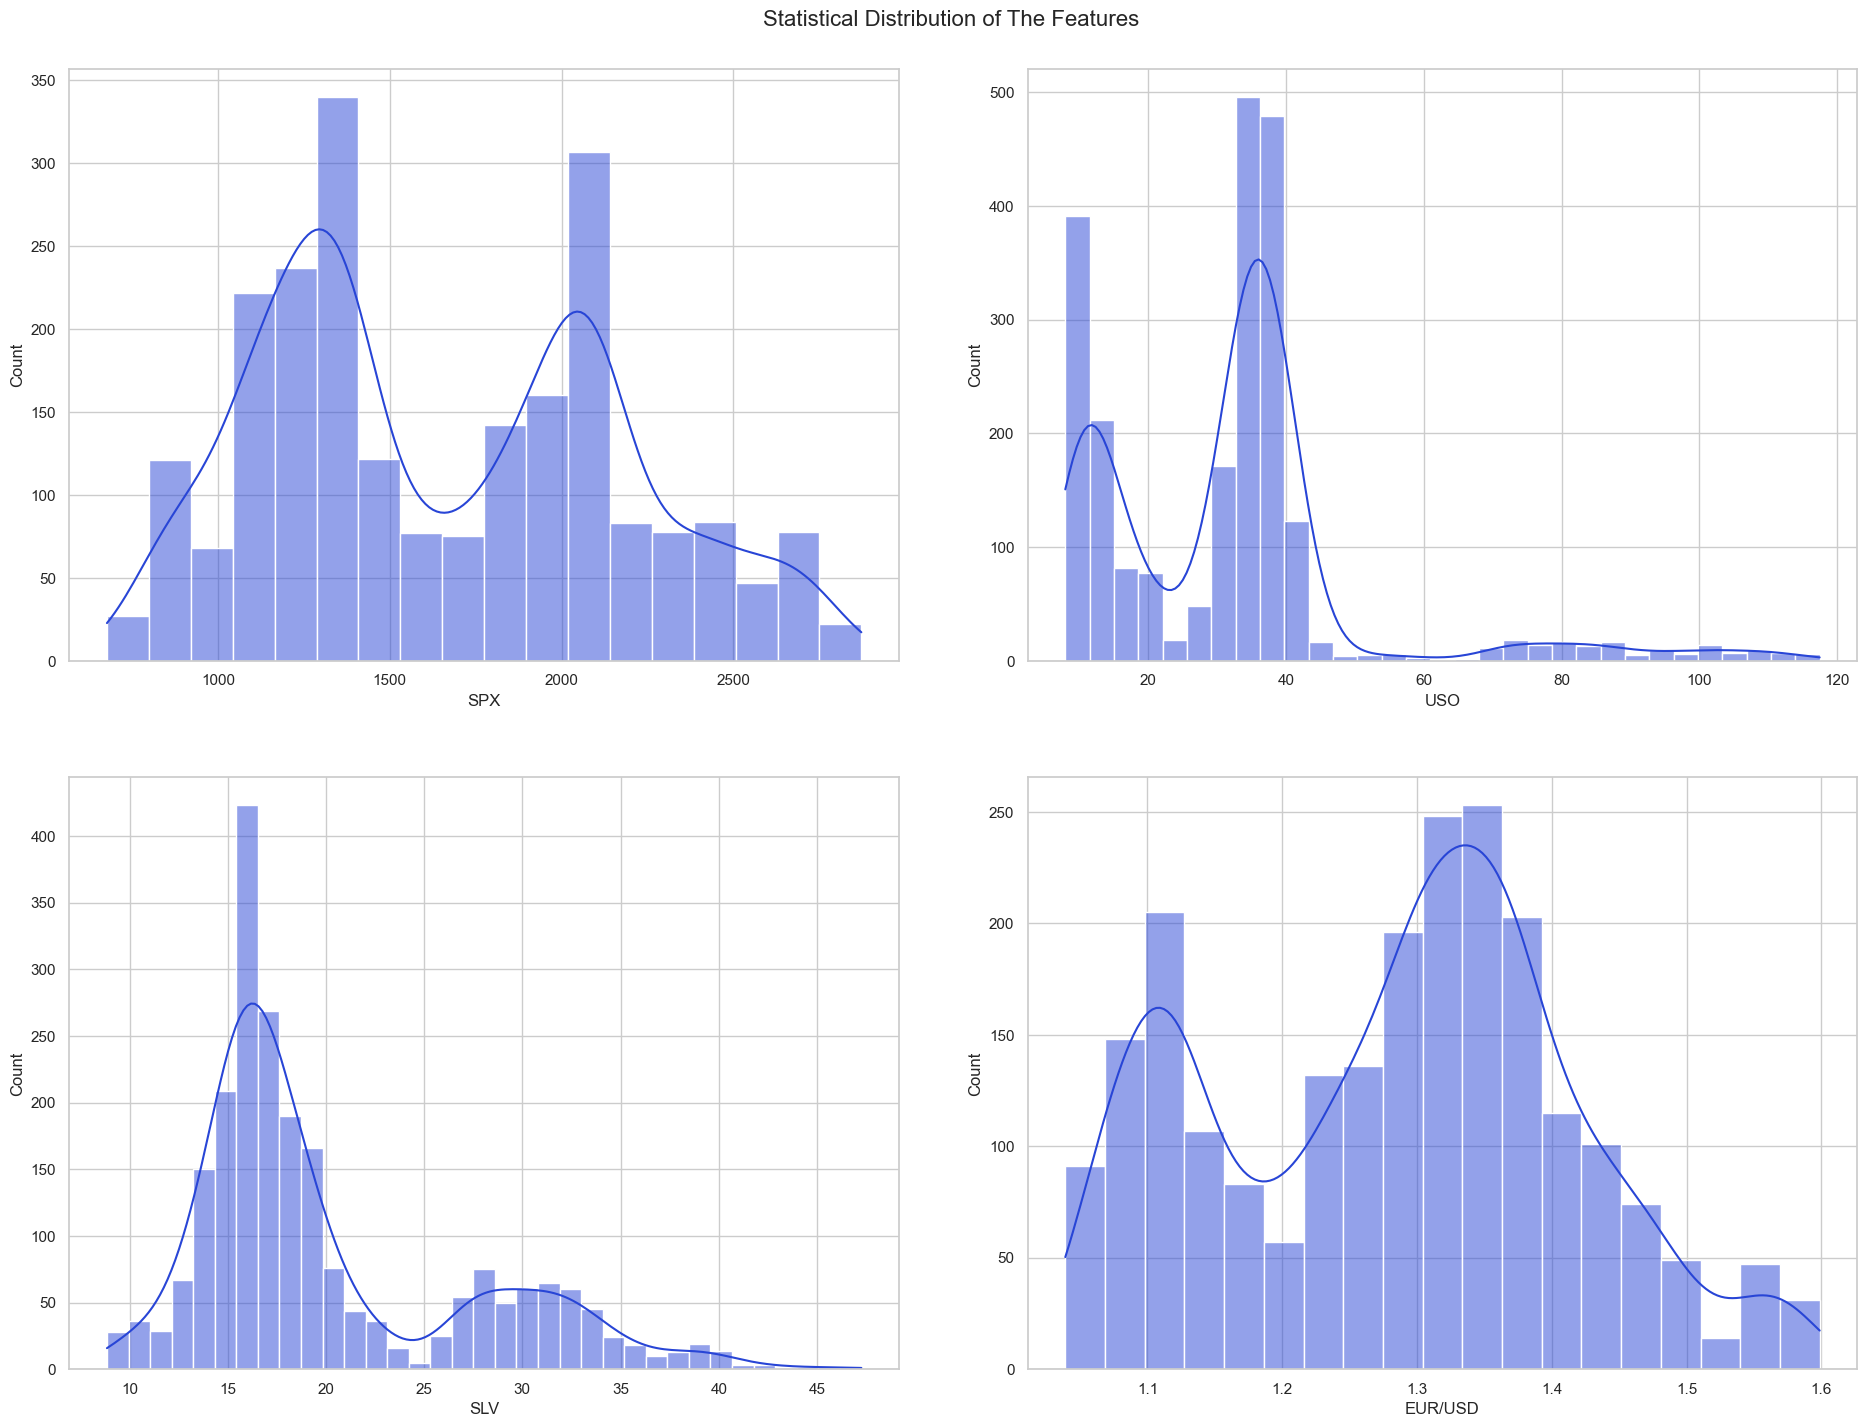

In [21]:
# create subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
axes = axes.flatten()

fig.tight_layout(pad=5.0)
fig.suptitle('Statistical Distribution of The Features', fontsize=16)

# plot histograms
for i, col in enumerate(features):
    sns.histplot(data=df, x=col, ax=axes[i], color="#2845D6", kde=True)

# remove unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.show()

**Plot Analysis**

**Key Observations**
| Feature       | Distribution Shape                | Characteristics                                                 |
| ------------- | --------------------------------- | --------------------------------------------------------------- |
| SPX           | Multi-Modal (3 peaks)             | Peaks at ~1300, ~2000-2100; Range: 700-2800                     |
| USO           | Highly Right-Skewed               | Peak at ~15, extreme tail to 120; 2008 spike visible            |
| SLV           | Multi-Modal (2-3 peaks)           | Peaks at ~16, ~30-33; Pattern mirrors GLD                       |
| EUR/USD       | Multi-Modal (2 peaks)             | Peaks at ~1.10, ~1.35; Most "normal" but still non-stationary   |

**Key Takeaways**
- All Features Confirm Non-Stationarity:
    - Multi-modal distributions = different market regimes over time
    - Just like GLD, all features violate normality assumptions
    - This is EXPECTED for financial price data
- USO is the Most Problematic:
    - Extreme right skew (2008 spike to ~$117)
    - Will dominate models if not transformed
    - Requires transformation most urgently
- SLV Confirms Strong Relationship with GLD:
    - Distribution pattern nearly identical to GLD
    - Both have peaks at similar time periods
- EUR/USD is Most Stable:
    - Narrower range (1.05-1.60)
    - Less extreme outliers
    - But still non-stationary

**Decisions/Actions**
- CRITICAL: Transform ALL Features to Returns
    - Raw prices CANNOT be used for modeling
    - Must convert to % change for:
        - Stationarity
        - Scale normalization
        - Model compatibility
- After Transformation, Expect:
    - Single-mode distributions centered at 0
    - Near-normal distribution (especially for EUR/USD, SPX)
    - Reduced skewness (especially for USO)
    - Outliers reduced from extreme values to % changes

#### ***Outliers Assesment of Other Features***

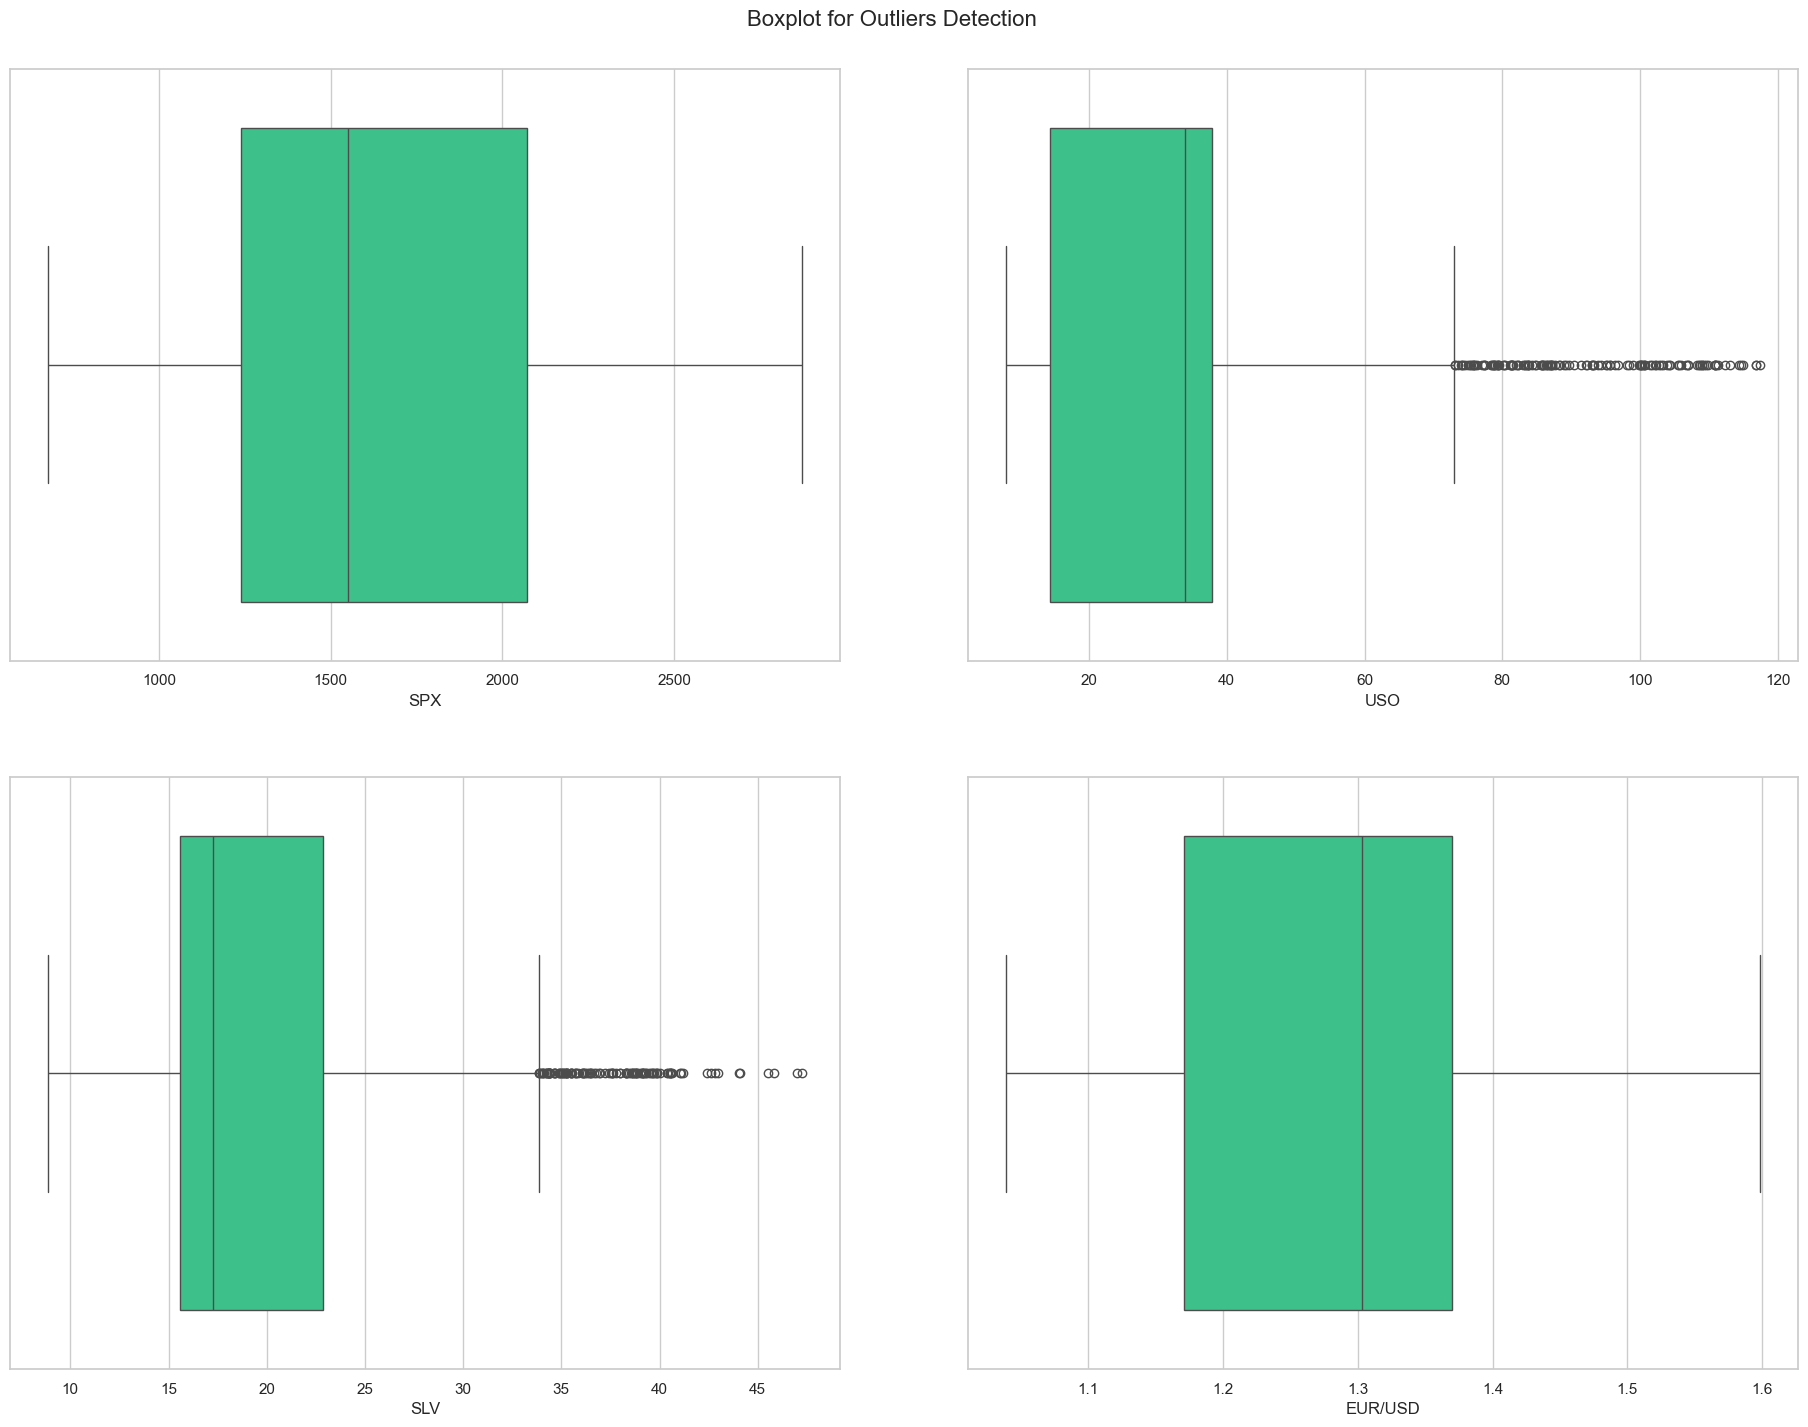

In [22]:
# create subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
fig.tight_layout(pad=5.0)
fig.suptitle('Boxplot for Outliers Detection', fontsize=16)

# loop through each column and plot on a different subplot
for i, col in enumerate(features):
    row_pos = i // cols
    col_pos = i % cols
    sns.boxplot(data=df, x=col, ax=axes[row_pos, col_pos], color="#28D68D")

# remove any empty subplots
for j in range(i+1, rows*cols):
    fig.delaxes(axes[j // cols, j % cols])

plt.show()

**Plot Analysis**

**Key Observations**
| Feature           | Box Position  | Outliers                        | Whisker Pattern            |
| ----------------- | --------------| --------------------------------| ---------------------------|
| SPX               | 1300-2100     | None visible                    | Symmetric, long whiskers   |
| USO               | 15-40         | Many upper outliers (70-120)    | Extreme upper whisker      |
| SLV               | 16-24         | Many upper outliers (35-47)     | Long upper whisker         |
| EUR/USD           | 1.18-1.38     | None visible                    | Symmetric, balanced        |

**Key Takeaways**
- USO - Most Extreme Outliers:
    - Upper outliers (70-120) = 2008 oil price spike
    - These are real market events, not errors
    - Will heavily influence model if not transformed
- SLV - Similar to GLD:
    - Upper outliers (35-47) = 2011 precious metals peak
    - Pattern mirrors GLD outliers (confirms strong relationship)
    - Same market forces driving both metals
- SPX & EUR/USD - No Extreme Outliers:
    - Boxplot shows "no outliers" by IQR method
    - But this is misleading - the entire series is non-stationary
    - The "outliers" are actually different market regimes embedded in the data
- Critical Insight: Boxplots on raw prices are misleading for time series data. What appears as `outliers` are actually:
    - Structural breaks (different market regimes)
    - Trend components (not random extreme values)
    - Real market events (financial crisis, commodity supercycle)

**Decisions/Actions:**
- DO NOT Remove Outliers:
    - These are valuable market signals
    - Removing them = removing important financial events
    - Models need to learn from these periods
- Transform to Returns (Reinforces Previous Decision):
    - Converting to % change will:
        - Normalize these "outliers" to reasonable % values
        - 2008 USO spike → becomes a large but reasonable % change
        - 2011 SLV peak → becomes a moderate % change
- After Transformation:
    - Outliers will be reduced to ±5-10% daily changes
    - Distribution will be centered at 0
    - Boxplots will show symmetric distributions with few extreme values

## **Data Transformation After Univariate Analysis**

### **Transform to Percentage Returns**

In [23]:
# define columns
cols = df.columns

# calculate percentage returns
df_returns = df[cols].pct_change()

# drop first row (NaN)
df_returns = df_returns.dropna()

# rename columns for clarity
df_returns.columns = [col.replace("/", "") + "_Return" for col in cols]

df_returns.shape

(2289, 5)

In [24]:
# transformation result
df_returns.head()

,SPX_Return,GLD_Return,USO_Return,SLV_Return,EURUSD_Return
Date,,,,,
2008-01-03,0.000000,0.008367,-0.001274,0.006917,0.001902
2008-01-04,-0.024552,-0.005142,-0.013526,-0.007720,0.000679
2008-01-07,0.003223,-0.004229,-0.023412,-0.007516,-0.004875
2008-01-08,-0.018352,0.023711,0.007417,0.035674,0.060478
2008-01-09,0.013624,-0.002650,-0.010649,-0.004490,-0.058245


In [25]:
# return descriptions
df_returns.describe()

,SPX_Return,GLD_Return,USO_Return,SLV_Return,EURUSD_Return
count,2289.000000,2289.000000,2289.000000,2289.000000,2289.000000
mean,0.000369,0.000244,-0.000460,0.000252,-0.000053
std,0.013582,0.012931,0.023667,0.021975,0.009321
min,-0.090350,-0.130685,-0.110739,-0.172659,-0.133526
25%,-0.004141,-0.005693,-0.012702,-0.009227,-0.003920
50%,0.000757,0.000494,0.000298,0.000634,-0.000071
75%,0.006030,0.006418,0.012062,0.010914,0.003875
max,0.107890,0.112905,0.139068,0.144231,0.173080


### **Transformation Verification**

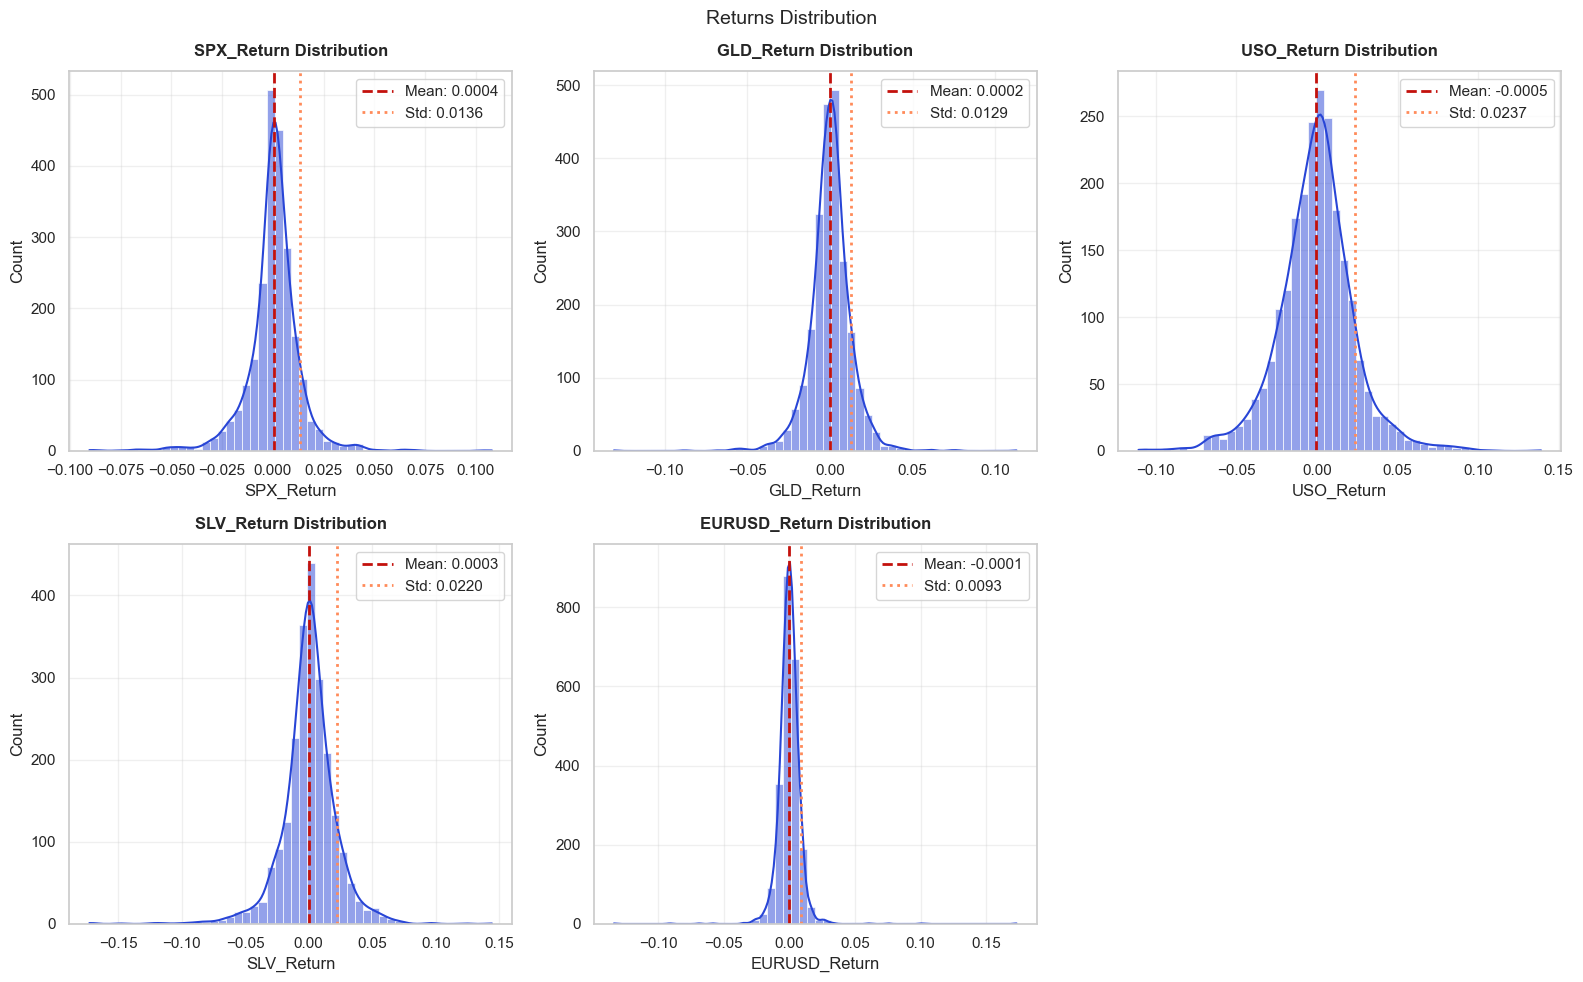

In [26]:
# 1. Check distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df_returns.columns):
    sns.histplot(df_returns[col], kde=True, ax=axes[i], bins=50, color='#2845D6')
    axes[i].axvline(df_returns[col].mean(), color='#C3110C', linestyle='--', linewidth=2, label=f"Mean: {df_returns[col].mean():.4f}")
    axes[i].axvline(df_returns[col].std(), color='#FF8B5A', linestyle=':', linewidth=2, label=f"Std: {df_returns[col].std():.4f}")
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold', y=1.02)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# remove empty subplots from the grid
for j in range(len(df_returns.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Returns Distribution', fontsize=14)
plt.tight_layout()
plt.show()

**Transformation Verification Report**
- What Went Well:
    - All 5 variables now show single-mode distributions (was multi-modal before)
    - All centered at 0 (means range from -0.0005 to 0.0004 - essentially zero)
    - Approximately normal (bell-shaped curves visible)
    - Massive improvement from raw price distributions

- Volatility Ranking (Std Dev):

| Variable      | Std Dev | Volatility Level         |
| ------------- | ------: | ------------------------ |
| SPX_Return    |  0.0136 | Low-Medium (1.36% daily) |
| GLD_Return    |  0.0129 | Low-Medium (1.29% daily) |
| USO_Return    |  0.0237 | Highest (2.37% daily)    |
| SLV_Return    |  0.0220 | High (2.20% daily)       |
| EURUSD_Return |  0.0093 | Lowest (0.93% daily)     |

- Minor Observations:
    - Slight right skew in SPX, GLD, USO (mean slightly > 0)
    - Leptokurtic distributions (sharper peaks than normal) - common in financial returns
    - This is NORMAL for financial returns - no action needed

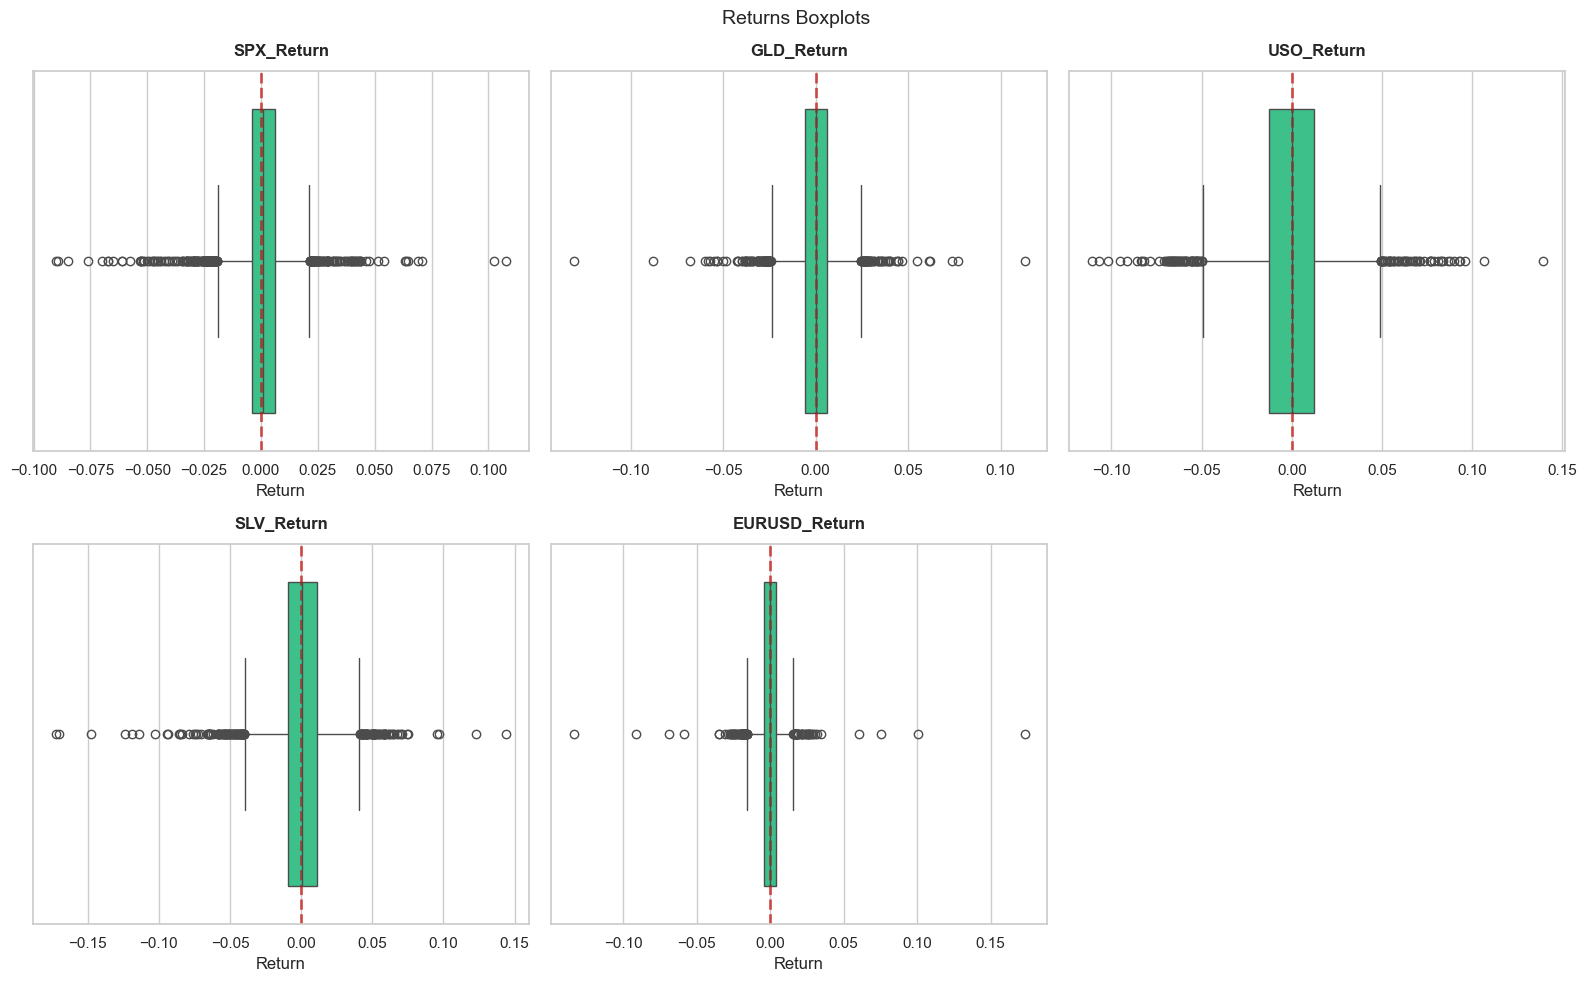

In [27]:
# 2. Check boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df_returns.columns):
    sns.boxplot(x=df_returns[col], ax=axes[i], color='#28D68D')
    axes[i].axvline(0, color='#C3110C', linestyle='--', linewidth=2, alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold', y=1.02)
    axes[i].set_xlabel('Return')

# remove empty subplots from the grid
for j in range(len(df_returns.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Returns Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

**Transformation Verification Report**
- What Went Well:
    - All boxes centered at 0 (red dashed line)
    - Symmetric distributions (boxes balanced around center)
    - Outliers on both sides (was only upper outliers before)
    - Outliers now reasonable
- Key Insights:
    - USO & SLV: Largest IQR (highest volatility) - matches time series behavior
    - EURUSD: Smallest IQR (most stable) - currency pairs typically less volatile
    - Outliers are REAL market events: 2008 crisis, 2011 volatility, etc.
    - DO NOT remove outliers - they're important for model learning

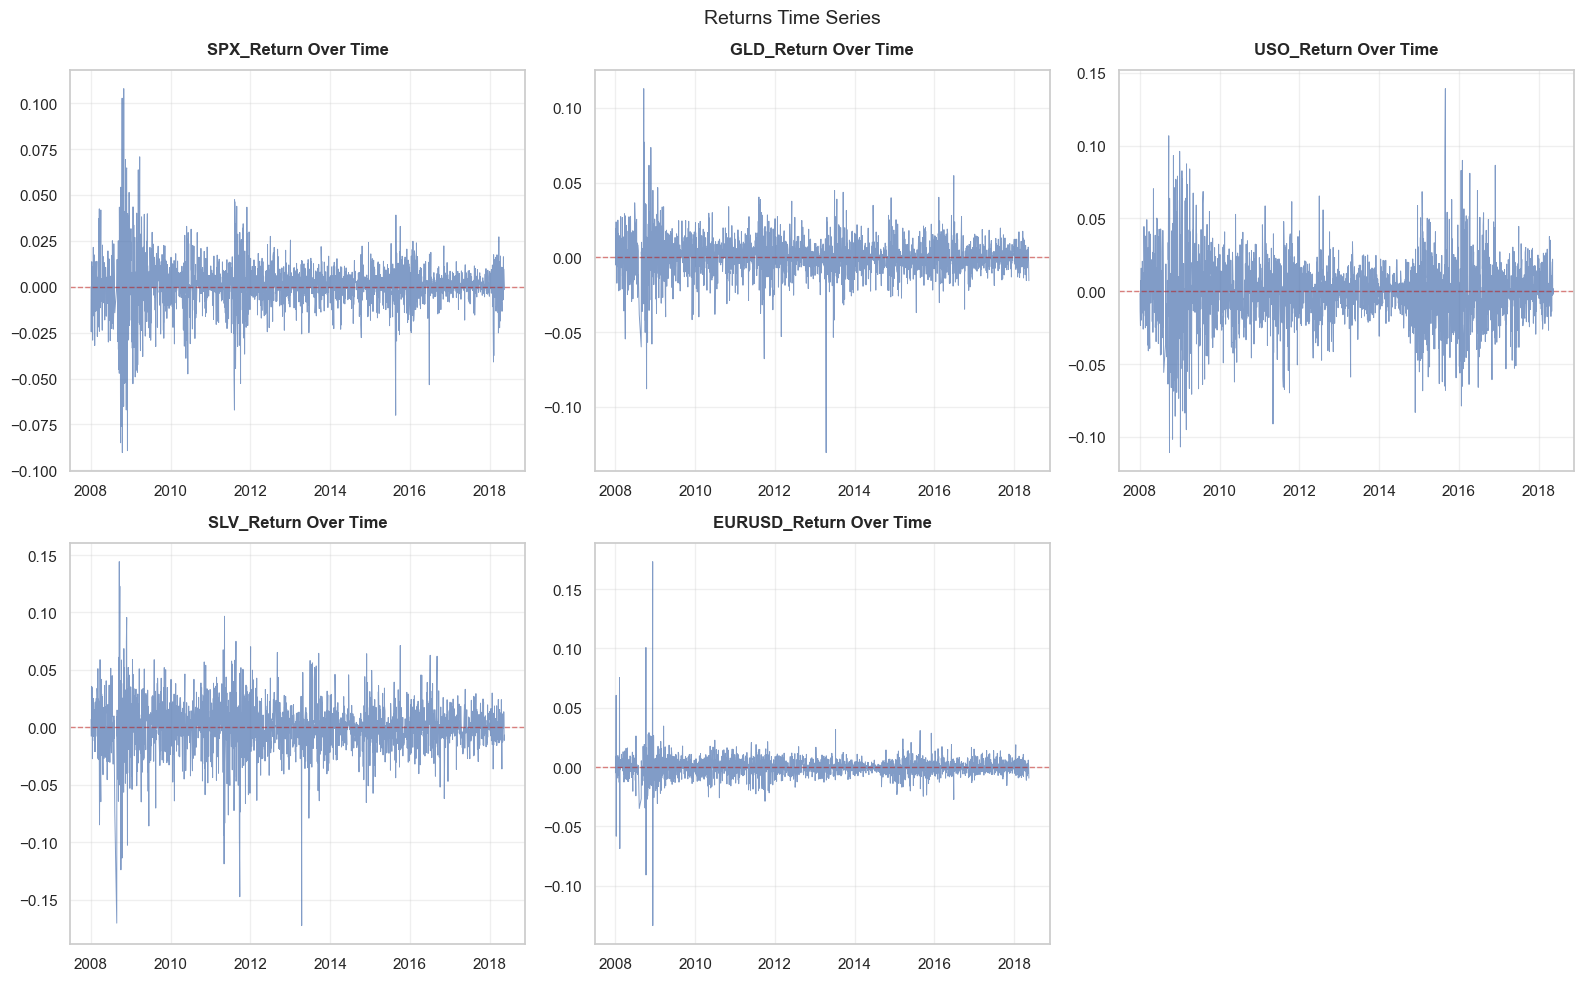

In [28]:
# 3. Time series of returns
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df_returns.columns):
    axes[i].plot(df_returns.index, df_returns[col], linewidth=0.7, alpha=0.7)
    axes[i].axhline(0, color='#C3110C', linestyle='--', linewidth=1, alpha=0.5)
    axes[i].set_title(f'{col} Over Time', fontsize=12, fontweight='bold', y=1.02)
    axes[i].grid(True, alpha=0.3)

# remove empty subplots from the grid
for j in range(len(df_returns.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Returns Time Series', fontsize=14)
plt.tight_layout()
plt.show()

**Transformation Verification Report**
- STATIONARITY ACHIEVED:
    - NO visible trends in any series (was strong trends before)
    - Mean constant at 0 across entire time period
    - Variance relatively stable (some volatility clustering, but no trend)
- Volatility Clustering Observed:
    - 2008-2009: High volatility across all assets (financial crisis)
    - 2011-2012: Moderate-high volatility (Eurozone crisis, gold peak)
    - 2016-2018: Lower, more stable volatility
- Important Note:
    - Volatility clustering is NORMAL in financial data (heteroscedasticity)
    - This is NOT non-stationarity - the mean is still constant
    - Models like GARCH can handle this, but for now, this is acceptable

### **Save Transformed Data**

In [29]:
# save processed data to as a new CSV file
file = Path("../data/gold_price_returns.csv")
df_returns.to_csv(file, index=False)

## **Bivariate Analysis**

### **Relationships Between Target and Other Features (Rerturn Relationship)**

#### **Scatter Plots (GLD vs Each Feature)**

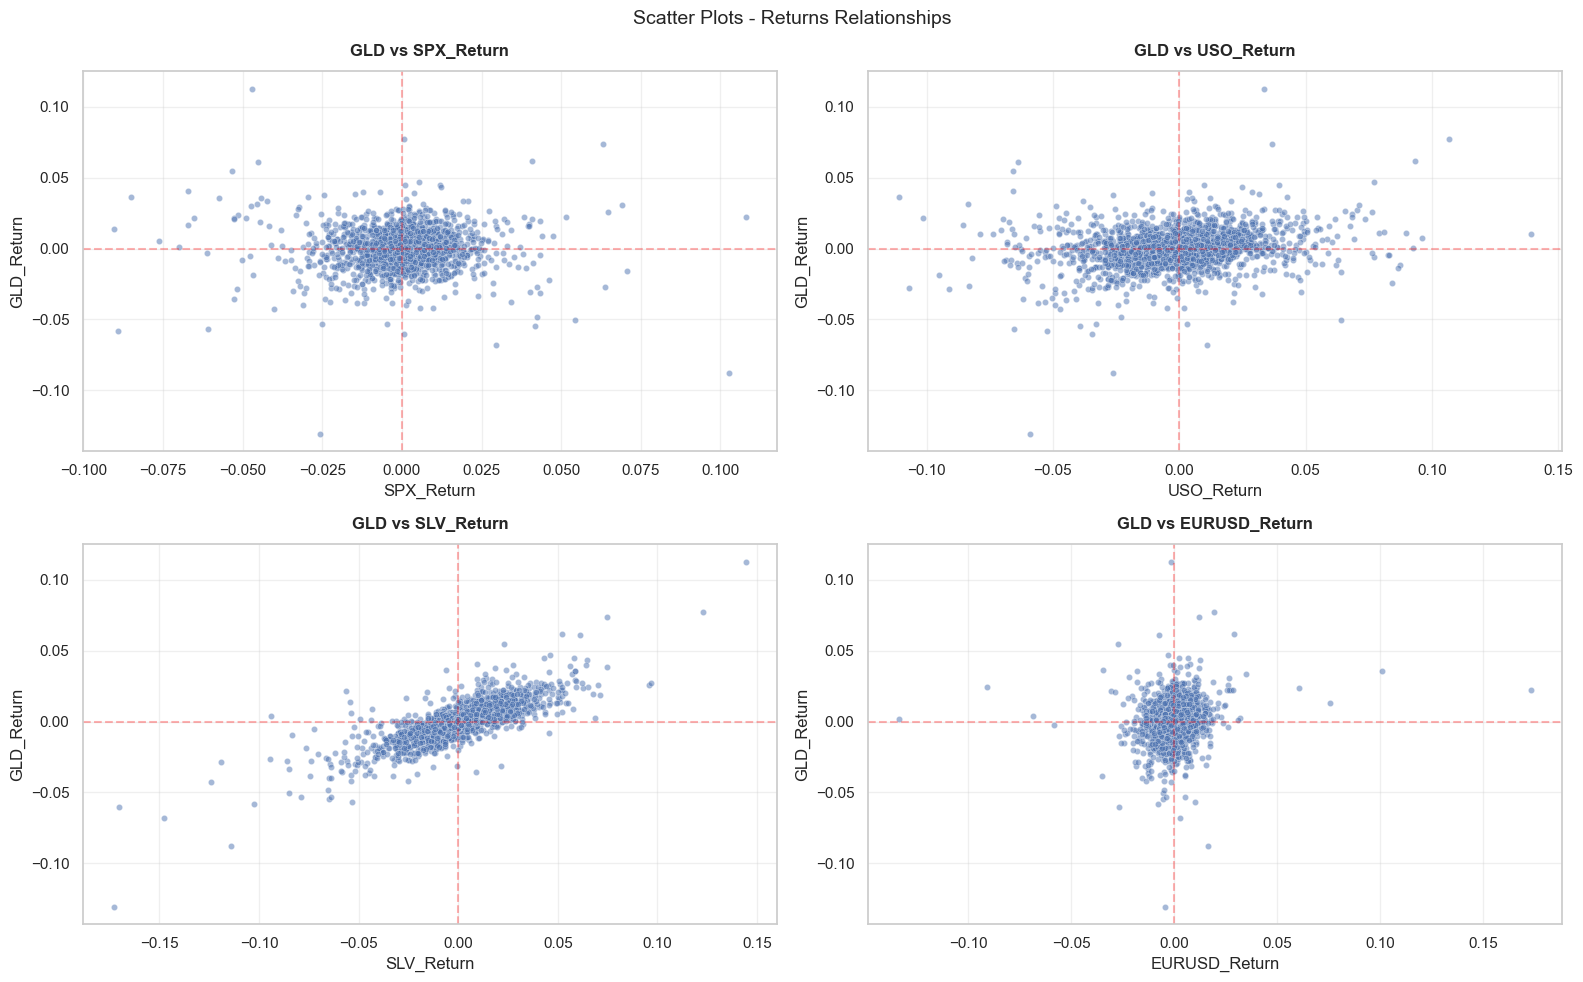

In [30]:
# figure setup
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

features = [col for col in df_returns.columns if col != 'GLD_Return']

for i, ft in enumerate(features):
    sns.scatterplot(x=df_returns[ft], y=df_returns['GLD_Return'], ax=axes[i], alpha=0.5, s=20)
    axes[i].set_xlabel(ft)
    axes[i].set_ylabel('GLD_Return')
    axes[i].set_title(f'GLD vs {ft}', fontsize=12, fontweight='bold',y=1.02)
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.3)
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.3)
    axes[i].grid(True, alpha=0.3)

# remove empty slots from the grid
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Scatter Plots - Returns Relationships', fontsize=14)
plt.tight_layout()
plt.show()

#### **Rolling Correlation**

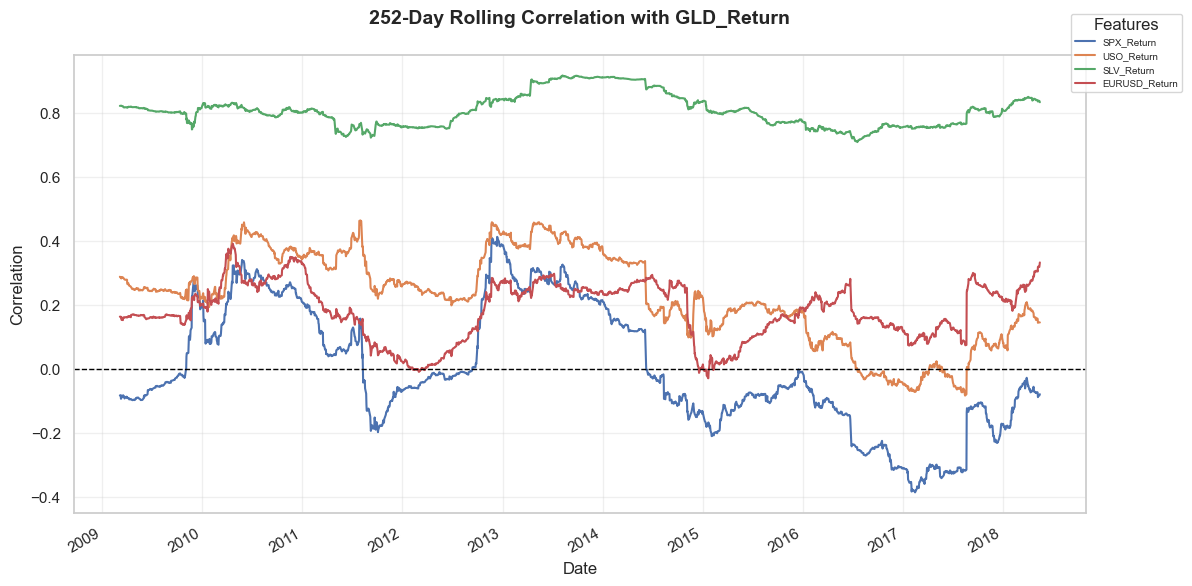

In [31]:
# figure size setup 
plt.figure(figsize=(12, 6))

# correlation plot
rolling_corr = df_returns[features].rolling(window=252).corr(df_returns['GLD_Return'])
rolling_corr.plot(ax=plt.gca())

# figure labels
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('252-Day Rolling Correlation with GLD_Return', fontsize=14, fontweight='bold', y=1.05)
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend(title='Features', loc='upper right', bbox_to_anchor=(1.1, 1.1), fontsize=7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### **Cross-Correlation Function (CCF)**

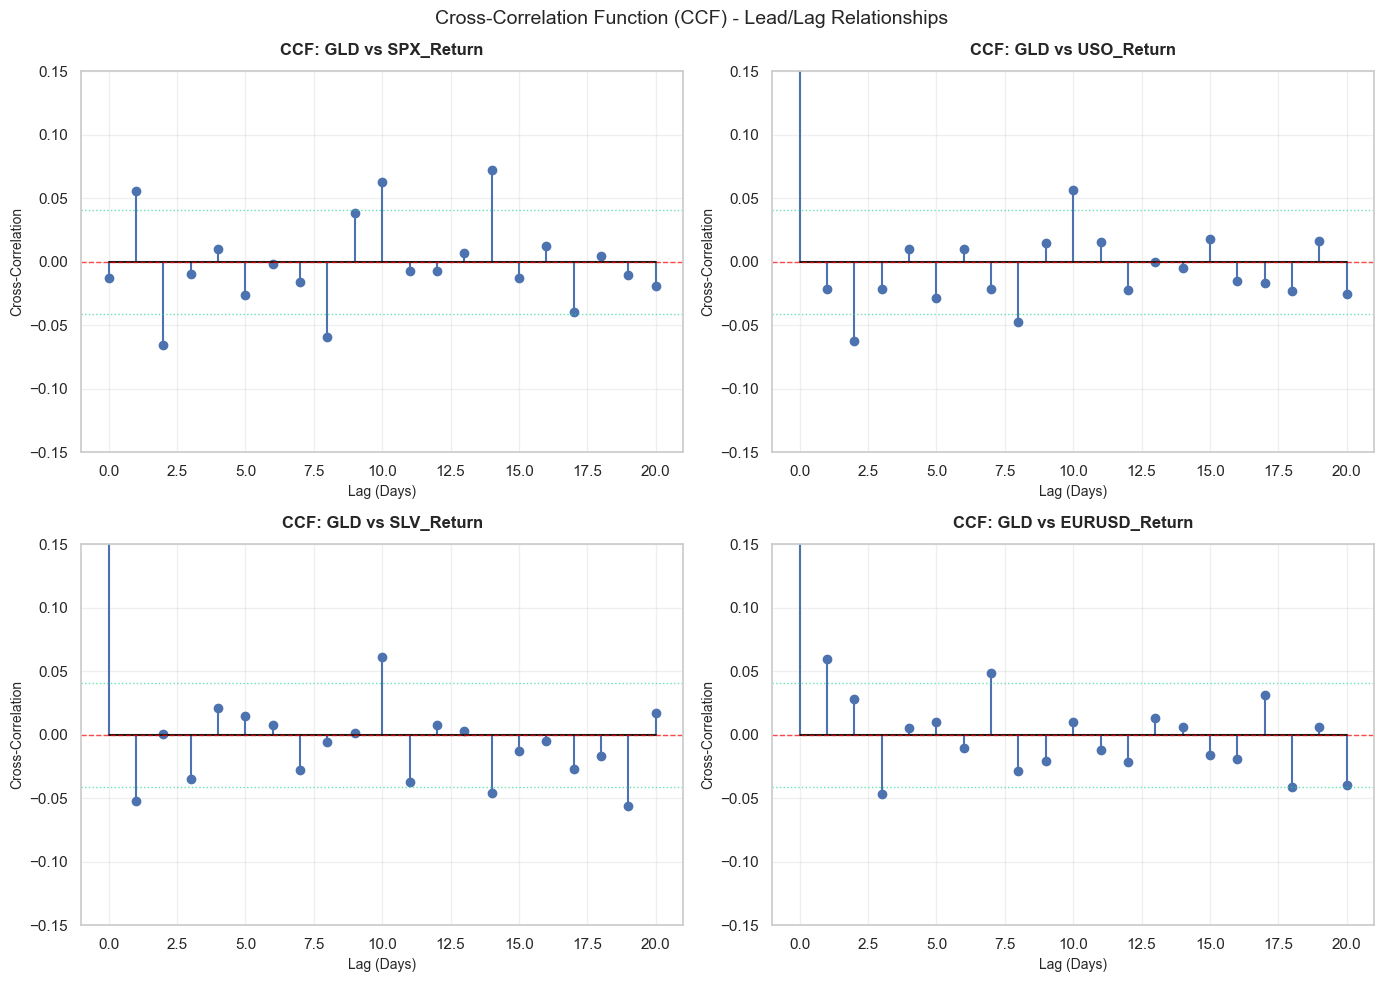

In [32]:
# import ccf
from statsmodels.tsa.stattools import ccf

# figure setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# check up to 20 days
max_lag = 20

for i, ft in enumerate(features):
    # calculate cross-correlation
    ccf_values = ccf(df_returns['GLD_Return'], df_returns[ft], adjusted=False)
    lags = range(0, max_lag + 1)
    ccf_lags = ccf_values[:max_lag + 1]
    
    # plot
    axes[i].stem(lags, ccf_lags, linefmt='b-', markerfmt='bo', basefmt='k-')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    # add significance bounds
    n = len(df_returns)
    significance_bound = 1.96 / np.sqrt(n)
    axes[i].axhline(significance_bound, color='#28D68D', linestyle=':', linewidth=1, alpha=0.7)
    axes[i].axhline(-significance_bound, color='#28D68D', linestyle=':', linewidth=1, alpha=0.7)
    
    # labels
    axes[i].set_xlabel('Lag (Days)', fontsize=10)
    axes[i].set_ylabel('Cross-Correlation', fontsize=10)
    axes[i].set_title(f'CCF: GLD vs {ft}', fontsize=12, fontweight='bold', y=1.02)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim([-0.15, 0.15])

plt.suptitle('Cross-Correlation Function (CCF) - Lead/Lag Relationships', fontsize=14)
plt.tight_layout()
plt.show()

**key findings**

In [33]:
# empty list for lag analysis data
lag_analysis = []

for ft in features:
    ccf_values = ccf(df_returns['GLD_Return'], df_returns[ft], adjusted=False)
    
    # find max correlation and its lag and check first 10 lags
    max_corr = np.max(np.abs(ccf_values[:11]))
    max_lag_idx = np.argmax(np.abs(ccf_values[:11]))

    lag_analysis.append({
        "Feature": ft,
        "Same_Day_Correlation": ccf_values[0],
        "Max_Correlation_0_to_10": ccf_values[max_lag_idx],
        "Lag_of_Max_Correlation(idx)": max_lag_idx,
        "Lag1_Correlation": ccf_values[1]
    })

# converted the result into datafram
ccf_summary = pd.DataFrame(lag_analysis).round(4)

In [34]:
# save the lags
file = Path(r"../data/ccf_lag_analysis_first_10.csv")
ccf_summary.to_csv(file, index=False)

In [35]:
ccf_summary

,Feature,Same_Day_Correlation,Max_Correlation_0_to_10,Lag_of_Max_Correlation(idx),Lag1_Correlation
0,SPX_Return,-0.0129,-0.0659,2,0.0559
1,USO_Return,0.2339,0.2339,0,-0.0214
2,SLV_Return,0.8066,0.8066,0,-0.0520
3,EURUSD_Return,0.1727,0.1727,0,0.0595


#### **Correlation Matrix**

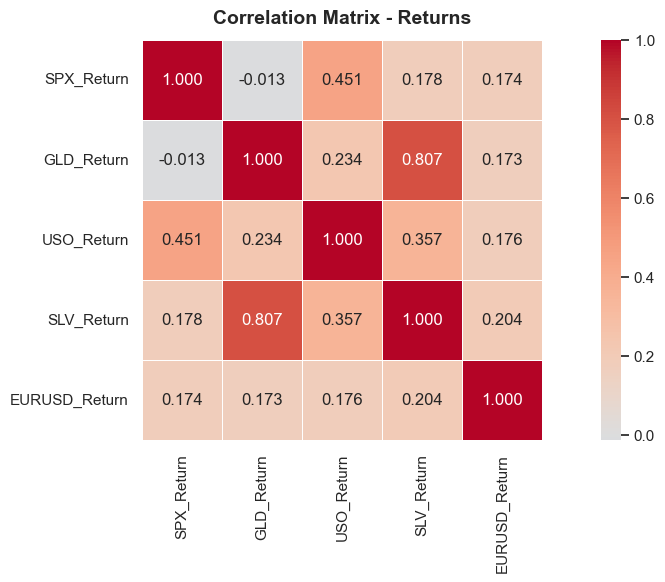

In [43]:
# figure sizing
plt.figure(figsize=(12, 6))

# correlation matrix
corr = df_returns.corr()

# correlation heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', linewidths=0.5, square=True)

# labels
plt.title('Correlation Matrix - Returns', fontsize=14, fontweight='bold',  y=1.02)
plt.tight_layout()
plt.show()

## **Multivariate Analysis**

# **Outliers Treatment**

# **Feature Engineering**

# **Save Data Before Modeling**